<a href="https://colab.research.google.com/github/shramith1/project1/blob/main/Weather_Rain_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [23]:
from google.colab import files
uploaded = files.upload()

Saving weather.csv to weather.csv


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [25]:
data = pd.read_csv("weather.csv")


print("Dataset Preview")
print(data.head())

Dataset Preview
   day  pressure  max_temp  temp  min_temp  dew_point  humidity  cloud  \
0    1      1012        32    30        26         22        78     40   
1    2      1010        34    31        27         23        80     50   
2    3      1008        28    26        24         22        90     80   
3    4      1013        33    30        26         21        70     30   
4    5      1007        27    25        23         21        92     85   

   rainfall  sunshine  wind_direction  wind_speed  rain  
0         0         8             120          10     0  
1         0         7             130          12     0  
2         5         2             140          14     1  
3         0         9             110           9     0  
4         7         1             150          15     1  


In [26]:
print("Dataset Information")
print(data.info())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   day             10 non-null     int64
 1   pressure        10 non-null     int64
 2   max_temp        10 non-null     int64
 3   temp            10 non-null     int64
 4   min_temp        10 non-null     int64
 5   dew_point       10 non-null     int64
 6   humidity        10 non-null     int64
 7   cloud           10 non-null     int64
 8   rainfall        10 non-null     int64
 9   sunshine        10 non-null     int64
 10  wind_direction  10 non-null     int64
 11  wind_speed      10 non-null     int64
 12  rain            10 non-null     int64
dtypes: int64(13)
memory usage: 1.1 KB
None


In [27]:
print("Statistical Summary")
print(data.describe())

Statistical Summary
            day    pressure   max_temp       temp   min_temp  dew_point  \
count  10.00000    10.00000  10.000000  10.000000  10.000000  10.000000   
mean    5.50000  1010.20000  30.800000  28.400000  25.100000  21.900000   
std     3.02765     2.65832   3.119829   2.716207   1.852926   0.737865   
min     1.00000  1006.00000  26.000000  24.000000  22.000000  21.000000   
25%     3.25000  1008.25000  28.250000  26.250000  24.000000  21.250000   
50%     5.50000  1010.50000  31.500000  29.500000  25.500000  22.000000   
75%     7.75000  1012.00000  33.000000  30.000000  26.000000  22.000000   
max    10.00000  1014.00000  35.000000  32.000000  28.000000  23.000000   

        humidity     cloud   rainfall  sunshine  wind_direction  wind_speed  \
count  10.000000  10.00000  10.000000  10.00000       10.000000    10.00000   
mean   80.800000  54.00000   2.500000   5.50000      126.000000    12.00000   
std     9.795691  25.14403   3.659083   3.62859       22.827858    

In [28]:
print("Missing Values")
print(data.isnull().sum())

Missing Values
day               0
pressure          0
max_temp          0
temp              0
min_temp          0
dew_point         0
humidity          0
cloud             0
rainfall          0
sunshine          0
wind_direction    0
wind_speed        0
rain              0
dtype: int64


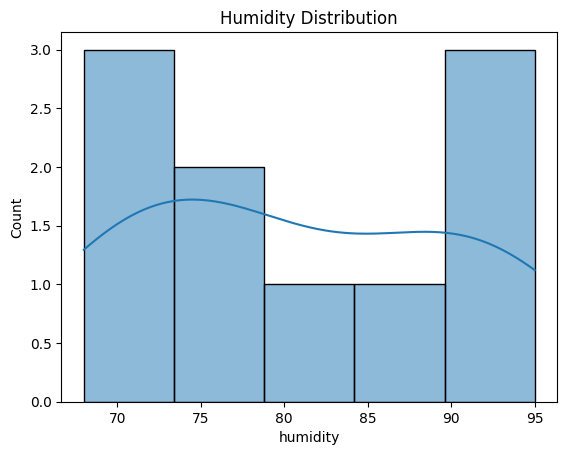

In [29]:
plt.figure()
sns.histplot(data["humidity"], kde=True)
plt.title("Humidity Distribution")
plt.show()

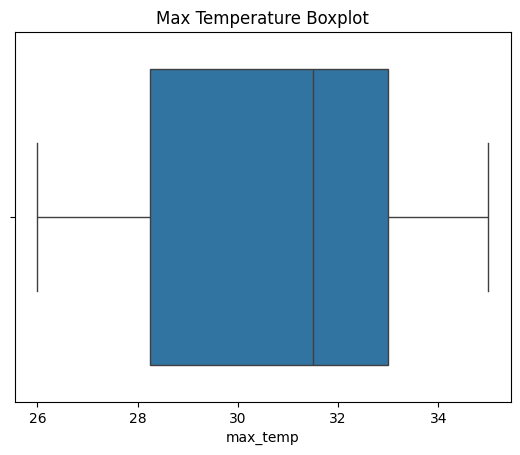

In [30]:
plt.figure()
sns.boxplot(x=data["max_temp"])
plt.title("Max Temperature Boxplot")
plt.show()

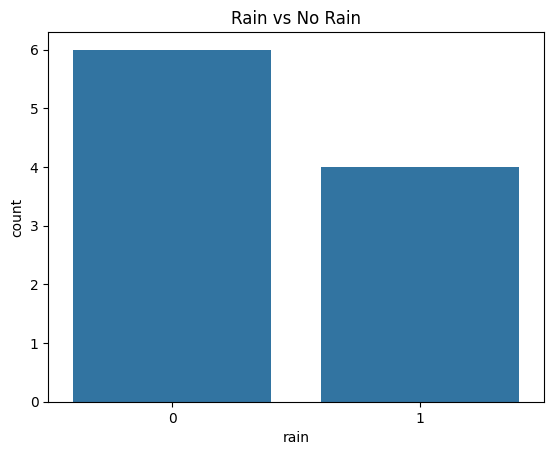

In [31]:
plt.figure()
sns.countplot(x=data["rain"])
plt.title("Rain vs No Rain")
plt.show()

In [32]:
X = data.drop("rain", axis=1)
y = data["rain"]

print(X.head())

   day  pressure  max_temp  temp  min_temp  dew_point  humidity  cloud  \
0    1      1012        32    30        26         22        78     40   
1    2      1010        34    31        27         23        80     50   
2    3      1008        28    26        24         22        90     80   
3    4      1013        33    30        26         21        70     30   
4    5      1007        27    25        23         21        92     85   

   rainfall  sunshine  wind_direction  wind_speed  
0         0         8             120          10  
1         0         7             130          12  
2         5         2             140          14  
3         0         9             110           9  
4         7         1             150          15  


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

Training Data Size: (8, 12)
Testing Data Size: (2, 12)


In [34]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 1.0


In [35]:
svc_model = SVC()

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)

print("SVC Accuracy:",
accuracy_score(y_test, svc_pred))

SVC Accuracy: 0.5


In [36]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:01:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


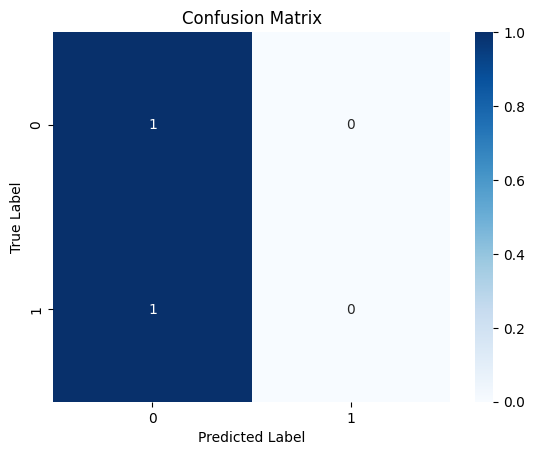

In [37]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [38]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
